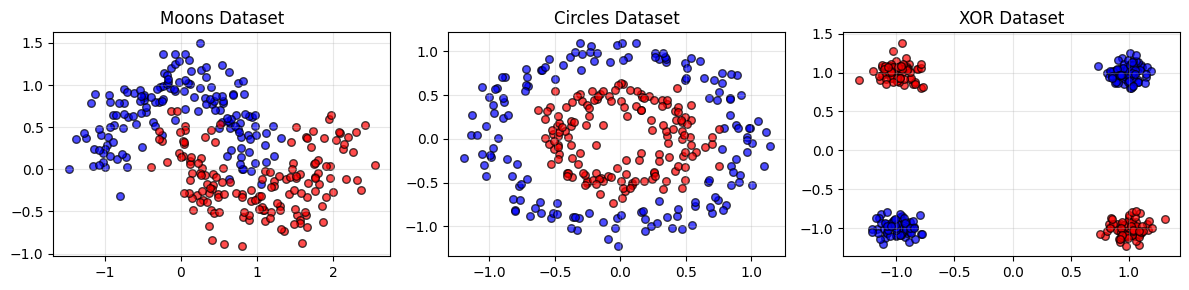

DECISION BOUNDARIES


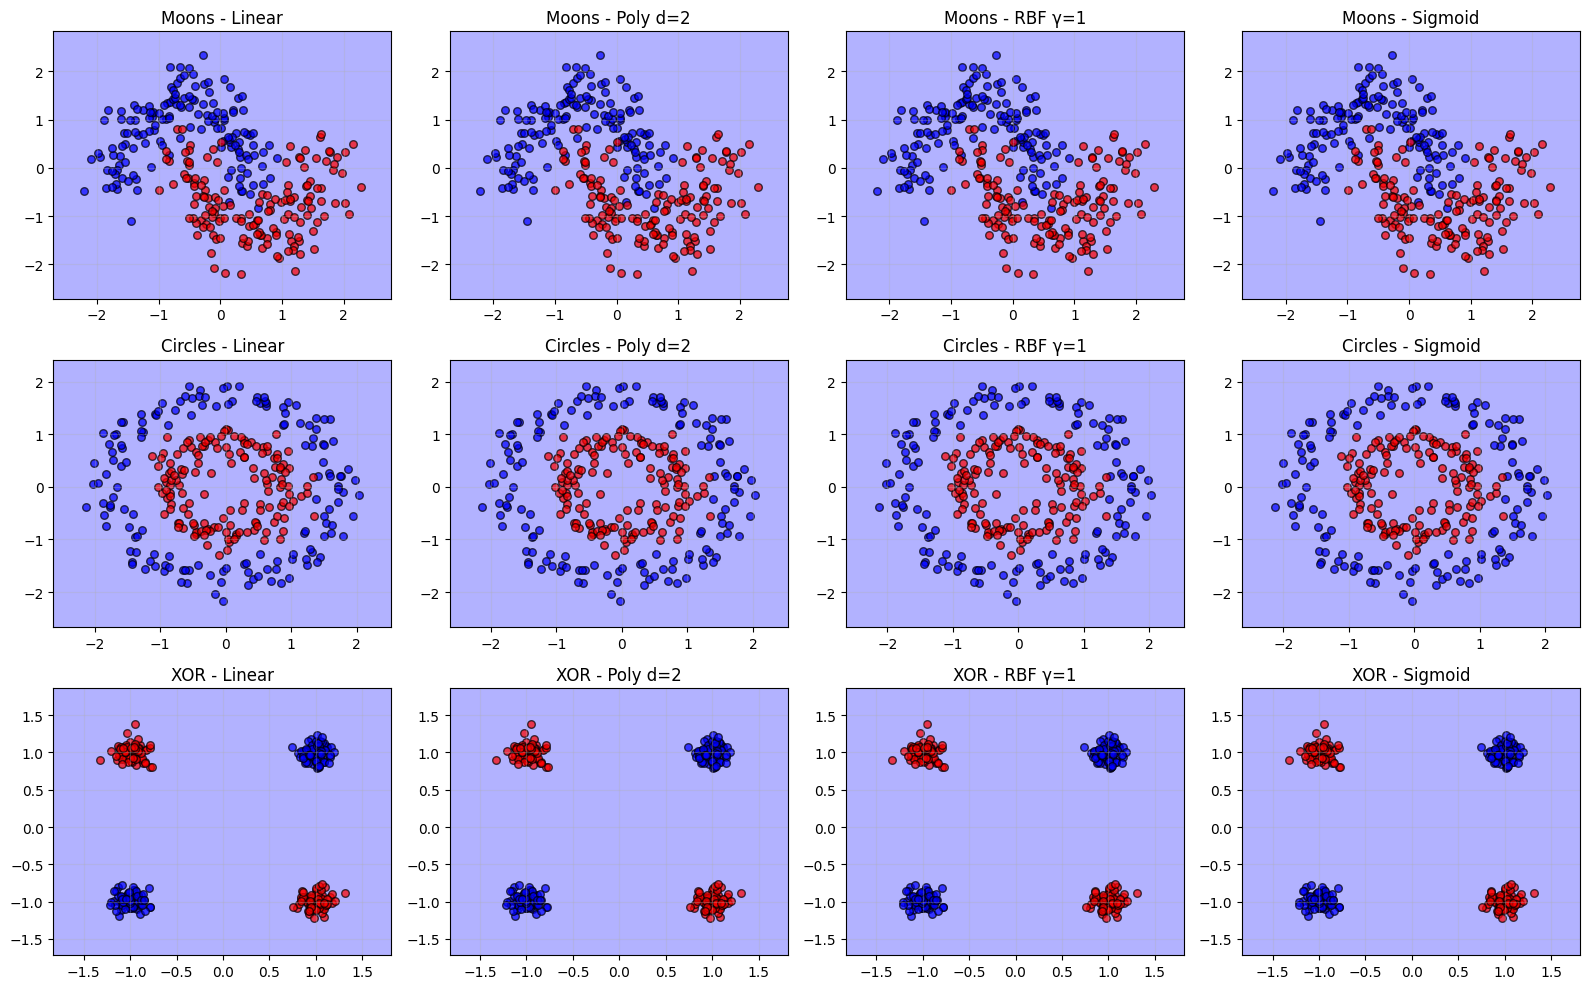

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

X_m, y_m = make_moons(300, noise=0.2, random_state=42); y_m = 2*y_m-1
X_c, y_c = make_circles(300, noise=0.1, random_state=42, factor=0.5); y_c = 2*y_c-1

X_x = np.random.randn(300,2)*0.1
y_x = np.array([-1]*75+[1]*75+[-1]*75+[1]*75)
X_x[:75]+=[1,1]; X_x[75:150]+=[-1,1]; X_x[150:225]+=[-1,-1]; X_x[225:]+=[1,-1]
idx=np.random.permutation(300); X_x,y_x=X_x[idx],y_x[idx]

fig,ax=plt.subplots(1,3,figsize=(12,3))
for i,(X,y,n) in enumerate([(X_m,y_m,'Moons'),(X_c,y_c,'Circles'),(X_x,y_x,'XOR')]):
    ax[i].scatter(X[y==-1,0],X[y==-1,1],c='blue',alpha=0.7,edgecolors='k',s=30)
    ax[i].scatter(X[y==1,0],X[y==1,1],c='red',alpha=0.7,edgecolors='k',s=30)
    ax[i].set_title(f'{n} Dataset'); ax[i].grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

class SVM:
    def __init__(self,C=1,kernel='linear',d=3,g='auto',c0=0):
        self.C,self.k,self.d,self.g,self.c0=C,kernel,d,g,c0
        self.a,self.b,self.sv,self.sv_y=None,0,None,None

    def _ker(self,X1,X2):
        if self.k=='linear': return X1@X2.T
        elif self.k=='poly': return (self.g*(X1@X2.T)+self.c0)**self.d
        elif self.k=='rbf':
            d=np.sum(X1**2,1)[:,None]+np.sum(X2**2,1)-2*X1@X2.T
            return np.exp(-self.g*d)
        elif self.k=='sigmoid': return np.tanh(self.g*(X1@X2.T)+self.c0)
        return X1@X2.T

    def fit(self,X,y):
        n=X.shape[0]
        self.g=1.0/(X.shape[1]*X.var()) if self.g=='auto' else self.g
        K=self._ker(X,X); self.a=np.zeros(n); self.b=0
        for _ in range(50):
            for i in range(n):
                g_i=np.sum(self.a*y*K[i])+self.b
                if y[i]*g_i<1 and self.a[i]<1 and self.a[i]>0:
                    self.a[i]-=0.1; self.b-=y[i]*0.01
        sv_idx=self.a>1e-3
        self.sv,self.sv_y=X[sv_idx],y[sv_idx]; self.a=self.a[sv_idx]
        if len(self.a)>0:
            self.b=np.mean(self.sv_y-self._ker(self.sv,self.sv)@(self.a*self.sv_y))
        return self

    def predict(self,X):
        if self.sv is None or len(self.sv)==0: return np.zeros(X.shape[0])
        return np.sign(self._ker(X,self.sv)@(self.a*self.sv_y)+self.b)

    def score(self,X,y): return accuracy_score(y,self.predict(X))

print("="*50+"\nDECISION BOUNDARIES\n"+"="*50)

kernels=[
    ('Linear',{'kernel':'linear'}),
    ('Poly d=2',{'kernel':'poly','d':2,'g':1}),
    ('RBF γ=1',{'kernel':'rbf','g':1}),
    ('Sigmoid',{'kernel':'sigmoid','g':0.1})
]

datasets=[('Moons',X_m,y_m),('Circles',X_c,y_c),('XOR',X_x,y_x)]

fig,ax=plt.subplots(3,4,figsize=(16,10))

for r,(dn,X,y) in enumerate(datasets):
    Xs=StandardScaler().fit_transform(X)
    h=0.02; x1,x2=Xs[:,0].min()-0.5,Xs[:,0].max()+0.5
    y1,y2=Xs[:,1].min()-0.5,Xs[:,1].max()+0.5
    xx,yy=np.meshgrid(np.arange(x1,x2,h),np.arange(y1,y2,h))
    for c,(kn,prm) in enumerate(kernels):
        svm=SVM(**prm).fit(Xs,y)
        Z=svm.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
        ax[r,c].contourf(xx,yy,Z,alpha=0.3,colors=['blue','red'])
        ax[r,c].contour(xx,yy,Z,levels=[0],colors='k',linewidths=2)
        ax[r,c].contour(xx,yy,Z,levels=[-1,1],colors='gray',linestyles='--',linewidths=1)
        ax[r,c].scatter(Xs[y==-1,0],Xs[y==-1,1],c='blue',alpha=0.7,edgecolors='k',s=30)
        ax[r,c].scatter(Xs[y==1,0],Xs[y==1,1],c='red',alpha=0.7,edgecolors='k',s=30)
        if svm.sv is not None and len(svm.sv)>0:
            ax[r,c].scatter(svm.sv[:,0],svm.sv[:,1],s=100,facecolors='none',edgecolors='y',linewidths=1.5)
        ax[r,c].set_title(f'{dn} - {kn}'); ax[r,c].grid(True,alpha=0.3)

plt.tight_layout(); plt.show()